# Optimización SVM con CV: Average Precision

GridSearchCV optimizando **Average Precision (PR-AUC)** con 3-fold CV.
Grilla moderada: C, gamma, class_weight. Se compara con baseline.

## 1. Importaciones

In [4]:
import sys
sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from pathlib import Path
from time import time
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)



repo_root = Path.cwd().resolve().parent
sys.path.insert(0, str(repo_root))

from SVM_model.pipeline import (
    load_data, clean_data, merge_smoking, get_train_test,
    build_preprocessor
)
import warnings
warnings.filterwarnings('ignore')
print('Ok')

c:\Users\juaji\AFI\trabajo_grupal_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ok


## 2. Datos
GridSearch sobre 20% del train (~16k) porque SVM RBF es O(n²).

In [5]:
df = load_data()
df = clean_data(df)
df = merge_smoking(df)
X = df.drop('diabetes', axis=1)
y = df['diabetes']
X_train, X_test, y_train, y_test = get_train_test(X, y)
X_gs, _, y_gs, _ = get_train_test(X_train, y_train, test_size=0.75)
print(f'GridSearch subset: {len(X_gs)} muestras')

GridSearch subset: 19987 muestras


## 3. Scoring: Average Precision (PR-AUC)
scoring='average_precision' (built-in sklearn).
Se reportan Precision, Recall, F1, PR-AUC, ROC-AUC.

In [38]:
print("Usando scoring='average_precision'")

Usando scoring='average_precision'


## 4. Pipeline Base
SVC con probability=True (necesario para average_precision).

In [39]:
preprocessor = build_preprocessor()
base_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(random_state=42, probability=True))
])
print('Ok')

Ok


## 5. Parámetros GridSearch
3 C × 2 gamma × 3 class_weight = 18 combos.

In [40]:
param_grid = {
    'svm__C': [0.1, 0.5, 1],
    'svm__gamma': ['scale', 0.01],
    'svm__class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 5}, {0: 1, 1: 10}]
}
total = 1
for v in param_grid.values():
    total *= len(v)
print(f'Combos: {total}, 3-fold CV => {total*3} fits')

Combos: 24, 3-fold CV => 72 fits


## 6. GridSearchCV (3-fold, optimizando Average Precision)

In [21]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    base_pipeline, param_grid,
    scoring='average_precision',
    cv=cv, n_jobs=-1, verbose=100
)
print('GridSearch sobre 25% del train...')
t0 = time()
grid_search.fit(X_gs, y_gs)
print(f'Completado en {time()-t0:.0f}s')
print(f'Mejor Average Precision (CV): {grid_search.best_score_:.4f}')

GridSearch sobre 20% del train...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Completado en 255s
Mejor Average Precision (CV): 0.8307


## 7. Mejores Parámetros + Refit Final
Refiteamos en train completo con los mejores parámetros.

In [22]:
print('Mejores parámetros:')
for p, v in grid_search.best_params_.items():
    print(f'  {p}: {v}')
best_C = grid_search.best_params_['svm__C']
best_cw = grid_search.best_params_['svm__class_weight']
print('\nRefiteando en train completo...')
t0 = time()
final_model = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('svm', SVC(kernel='rbf', C=best_C, gamma='scale',
                class_weight=best_cw, probability=True, random_state=42))
])
final_model.fit(X_train, y_train)
print(f'Refit listo ({time()-t0:.0f}s)')

Mejores parámetros:
  svm__C: 1
  svm__class_weight: {0: 1, 1: 5}
  svm__gamma: scale

Refiteando en train completo...
Refit listo (1073s)


## 8. Evaluación en Test

In [23]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print('Métricas en Test:')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')
print(f'  PR-AUC:    {pr_auc:.4f}')
print(f'  ROC-AUC:   {roc_auc:.4f}\n')
print('Matriz Confusión:')
print(f'  TN:{tn:5d}  FP:{fp:5d}')
print(f'  FN:{fn:5d}  TP:{tp:5d}')
print(f'\n{classification_report(y_test, y_pred, target_names=["No Diabetes","Diabetes"])}')

Métricas en Test:
  Precision: 0.6358
  Recall:    0.8167
  F1-Score:  0.7150
  PR-AUC:    0.8558
  ROC-AUC:   0.9701

Matriz Confusión:
  TN:17496  FP:  794
  FN:  311  TP: 1386

              precision    recall  f1-score   support

 No Diabetes       0.98      0.96      0.97     18290
    Diabetes       0.64      0.82      0.71      1697

    accuracy                           0.94     19987
   macro avg       0.81      0.89      0.84     19987
weighted avg       0.95      0.94      0.95     19987



Features: 10
Entrenando SVM pequeno para SHAP (10000 muestras)...
SVM pequeno listo en 2s
SV: 1013
SHAP values...


100%|██████████| 50/50 [00:33<00:00,  1.51it/s]


SHAP listo en 33s


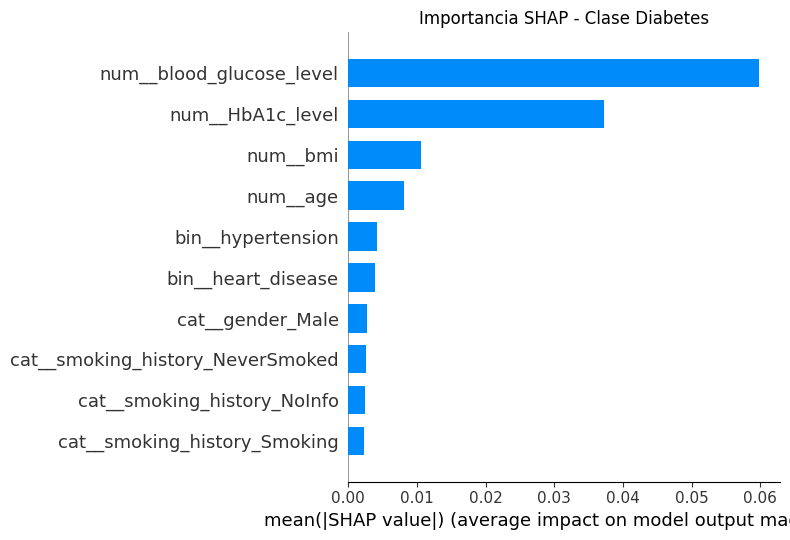

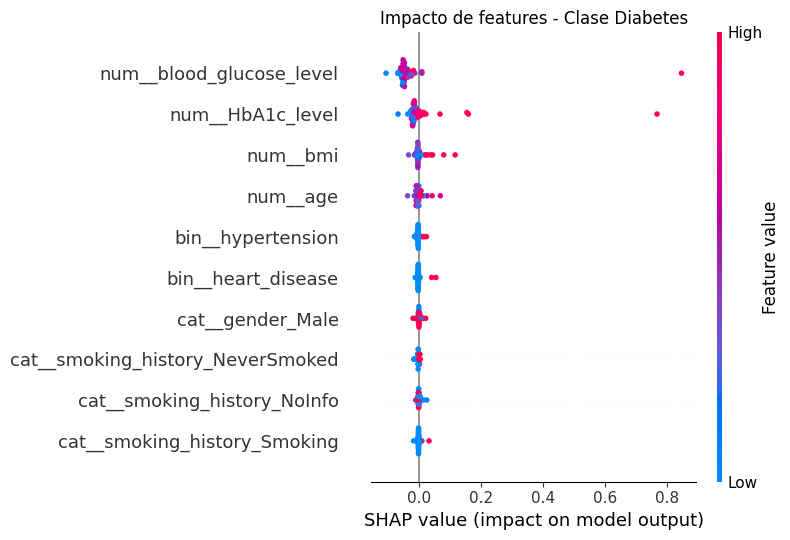

In [26]:
import time
# SHAP con SVM pequeno (KernelExplainer en modelo grande es inviable)
# Entrenamos un SVM ligero en 10000 muestras solo para SHAP
Xp_train = final_model.named_steps['preprocessor'].transform(X_train)
Xp_test = final_model.named_steps['preprocessor'].transform(X_test)
fnames = list(final_model.named_steps['preprocessor'].get_feature_names_out())
print(f'Features: {len(fnames)}')

rng = np.random.default_rng(42)
idx = rng.choice(Xp_train.shape[0], 10000, replace=False)
X_sub = Xp_train[idx]
y_sub = y_train.values[idx] if hasattr(y_train, 'values') else y_train[idx]
print(f'Entrenando SVM pequeno para SHAP ({X_sub.shape[0]} muestras)...')
from sklearn.svm import SVC as SVC_shap
svm_shap = SVC_shap(kernel='rbf', probability=True, random_state=42)
t0 = time.time()
svm_shap.fit(X_sub, y_sub)
print(f'SVM pequeno listo en {time.time()-t0:.0f}s')
print(f'SV: {sum(svm_shap.n_support_)}')

bg = Xp_train[rng.choice(Xp_train.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(svm_shap.predict_proba, bg)
X_shap = Xp_test[rng.choice(Xp_test.shape[0], 50, replace=False)]
print('SHAP values...')
t0 = time.time()
sv = explainer.shap_values(X_shap, nsamples=100)
print(f'SHAP listo en {time.time()-t0:.0f}s')
n = X_shap.shape[0]
if len(sv) == 2 and sv[0].shape[0] == n:
    shap_class1 = sv[1]
else:
    shap_class1 = np.array([sv_i[:, 1] for sv_i in sv])

if shap_class1.shape[1] == X_shap.shape[1]:
    feat = fnames[:shap_class1.shape[1]]
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, plot_type='bar', show=False)
    plt.title('Importancia SHAP - Clase Diabetes')
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, show=False)
    plt.title('Impacto de features - Clase Diabetes')
    plt.tight_layout(); plt.show()
else:
    print(f'Shape mismatch: shap_class1={shap_class1.shape} vs X_shap={X_shap.shape}')


## 9. Guardar Modelo + Comparar con Baseline
Baseline = C=1, class_weight='balanced', gamma='scale' (valores de referencia).

In [ ]:
import joblib, json, os
os.makedirs('artifacts', exist_ok=True)

# ── 1. Guardar si viene de gridsearch, cargar si ya existe ───────────────
MODEL_PATH  = 'artifacts/svm_model_optimized_cv.pkl'
PARAMS_PATH = 'artifacts/best_params_cv.json'

# Intentar usar final_model (gridsearch recién ejecutado)
if 'final_model' in dir():
    joblib.dump(final_model, MODEL_PATH)
    with open(PARAMS_PATH, 'w') as f:
        json.dump(grid_search.best_params_, f, indent=2)
    print('Modelo guardado desde gridsearch.')
    opt_model = final_model

# Si no, intentar cargar svm_model_optimized (ya en memoria)
elif 'svm_model_optimized' in dir():
    joblib.dump(svm_model_optimized, MODEL_PATH)
    print('Modelo guardado desde svm_model_optimized en memoria.')
    opt_model = svm_model_optimized

# Si no, cargar desde disco
elif os.path.exists(MODEL_PATH):
    opt_model = joblib.load(MODEL_PATH)
    print('Modelo cargado desde disco.')

else:
    raise FileNotFoundError('No hay modelo disponible. Ejecuta el gridsearch primero.')

# ── 2. Predecir ──────────────────────────────────────────────────────────
y_pred  = opt_model.predict(X_test)
y_proba = opt_model.predict_proba(X_test)[:, 1]


# ── 3. Baseline ──────────────────────────────────────────────────────────
base_metrics = {
    'Precision': 0.4433, 'Recall': 0.9287, 'F1': 0.6002,
    'PR-AUC': 0.8526, 'ROC-AUC': 0.9736
}
try:
    bl = joblib.load('artifacts/svm_model_trained.pkl')
    y_pred_base  = bl.predict(X_test)
    y_proba_base = bl.predict_proba(X_test)[:, 1]
    cm_base      = confusion_matrix(y_test, y_pred_base)
except Exception:
    print('Modelo baseline no encontrado, usando valores de referencia.')
    y_pred_base = y_proba_base = cm_base = None

# ── 4. Comparación ───────────────────────────────────────────────────────
try:
    opt_metrics = {
        'Precision': precision, 'Recall': recall, 'F1': f1,
        'PR-AUC': pr_auc, 'ROC-AUC': roc_auc
    }
except Exception:
    opt_metrics = {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
comp = pd.DataFrame({'Baseline': base_metrics, 'Optimizado': opt_metrics})
comp['Mejora'] = comp['Optimizado'] - comp['Baseline']
print('\nComparación vs Baseline:')
print(comp.round(4).to_string())

Modelo cargado desde disco.

Comparación vs Baseline:
           Baseline  Optimizado  Mejora
Precision    0.4433      0.6358  0.1925
Recall       0.9287      0.8167 -0.1120
F1           0.6002      0.7150  0.1148
PR-AUC       0.8526      0.8558  0.0032
ROC-AUC      0.9736      0.9701 -0.0035


In [41]:
test_met = {
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'pr_auc': float(pr_auc),
    'roc_auc': float(roc_auc)
}
baseline_metrics = {
    'Precision': 0.4433, 'Recall': 0.9287, 'F1': 0.6002,
    'PR-AUC': 0.8526, 'ROC-AUC': 0.9736
}

try:
    cv_metrics = {
        'best_avg_precision': float(grid_search.best_score_),
        'n_splits': 3,
        'combinations': int(total),
        'subset_size': len(X_gs)
    }
except Exception as e:
    print(f'Error obteniendo métricas CV: {e}')
    cv_metrics = {
        'best_avg_precision': 0.8307,
        'n_splits': 3,
        'combinations': 72,
        'subset_size': len(X_gs)
    }


metrics_dict = {
    'test': test_met,
    'baseline': {k.lower().replace('-','_'): float(v) for k, v in baseline_metrics.items()},
    'cv': cv_metrics,
    'confusion_matrix': {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}
}
with open('artifacts/metrics_optimized_cv.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print('Modelo y métricas guardados en artifacts/')
if recall >= 0.9:
    print(f'OK: Recall={recall:.1%} >= 90% (objetivo cumplido)')
else:
    print(f'WARNING: Recall={recall:.1%} < 90% (ajustar parámetros)')

Error obteniendo métricas CV: name 'grid_search' is not defined
Modelo y métricas guardados en artifacts/


## 10. Curva Precision-Recall (Optimizado vs Baseline)

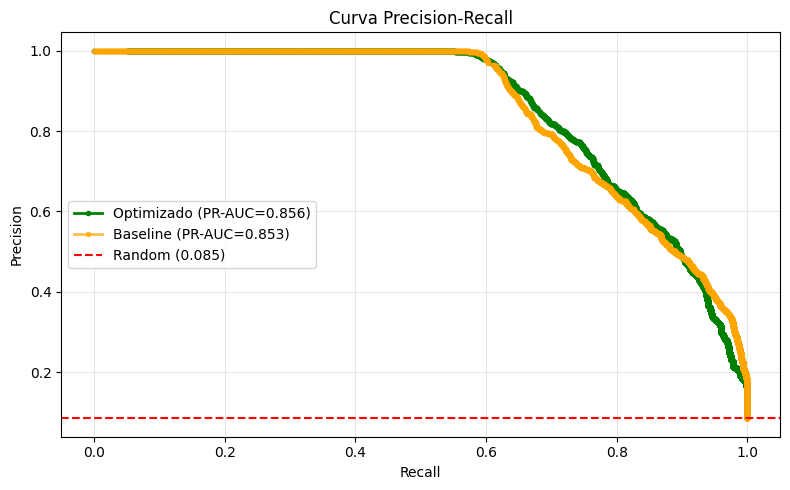

Guardado: cv_pr_curve.png


In [42]:
pr, re, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(re, pr, marker='.', label=f'Optimizado (PR-AUC={pr_auc:.3f})', color='green', lw=2)
if y_proba_base is not None:
    pr_b, re_b, _ = precision_recall_curve(y_test, y_proba_base)
    ax.plot(re_b, pr_b, marker='.', label=f'Baseline (PR-AUC={base_metrics["PR-AUC"]:.3f})', color='orange', lw=2, alpha=0.7)
ax.axhline(y=y_test.mean(), color='red', ls='--', label=f'Random ({y_test.mean():.3f})')
ax.set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cv_pr_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print('Guardado: cv_pr_curve.png')

## 11. Threshold Tuning
Ajustamos el umbral para balancear Precision-Recall sin reentrenar.

Threshold óptimo (CV F2): 0.05
  Precision: 0.4897
  Recall:    0.8998
  F2:        0.8303
  F1:        0.6343


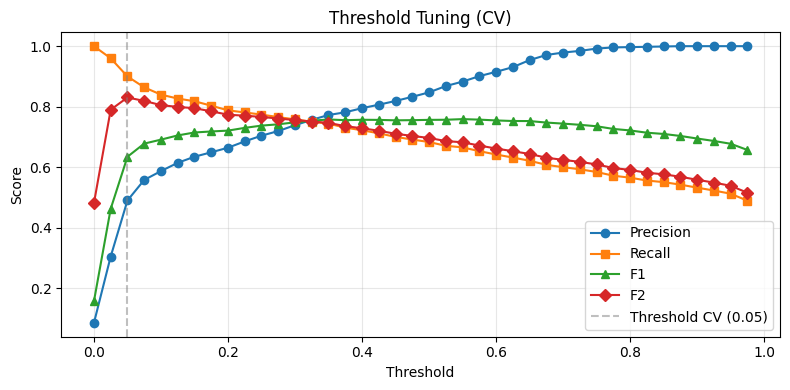


Comparación: default (0.5) vs óptimo (0.05)


NameError: name 'recall' is not defined

In [15]:
from sklearn.metrics import fbeta_score
from sklearn.model_selection import StratifiedKFold

if 'model' not in dir():
    model = opt_model

# ── 1. Elegir threshold con CV sobre TRAIN (sin tocar test) ──────────────
thresholds = np.arange(0.0, 1, 0.025)
cv_scores = {t: [] for t in thresholds}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model.fit(X_tr, y_tr)
    y_proba_val = model.predict_proba(X_val)[:, 1]

    for t in thresholds:
        y_pred_t = (y_proba_val >= t).astype(int)
        cv_scores[t].append(fbeta_score(y_val, y_pred_t, beta=3, zero_division=0))

best_threshold = max(cv_scores, key=lambda t: np.mean(cv_scores[t]))

# ── 2. Reentrenar con TODO train ─────────────────────────────────────────
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]   # probabilidades finales sobre test

# ── 3. Gráfica sobre test (solo visualización, threshold ya fijado) ──────
scores = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    scores.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
        'f2':        fbeta_score(y_test, y_pred_t, beta=3, zero_division=0)
    })
df_t = pd.DataFrame(scores)

# Fila con el threshold elegido por CV (no el máximo de test)
best_t = df_t[df_t['threshold'] == best_threshold].iloc[0]

print(f'Threshold óptimo (CV F2): {best_threshold:.2f}')
print(f'  Precision: {best_t["precision"]:.4f}')
print(f'  Recall:    {best_t["recall"]:.4f}')
print(f'  F2:        {best_t["f2"]:.4f}')
print(f'  F1:        {best_t["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_t['threshold'], df_t['precision'], label='Precision', marker='o')
ax.plot(df_t['threshold'], df_t['recall'],    label='Recall',    marker='s')
ax.plot(df_t['threshold'], df_t['f1'],        label='F1',        marker='^')
ax.plot(df_t['threshold'], df_t['f2'],        label='F2',        marker='D')
ax.axvline(x=best_threshold, color='gray', ls='--', alpha=0.5,
           label=f'Threshold CV ({best_threshold:.2f})')
ax.set(xlabel='Threshold', ylabel='Score', title='Threshold Tuning (CV)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nComparación: default (0.5) vs óptimo ({best_threshold:.2f})')
print(f'  Recall default:    {recall:.4f}  ->  óptimo: {best_t["recall"]:.4f}')
print(f'  Precision default: {precision:.4f}  ->  óptimo: {best_t["precision"]:.4f}')

## 12. Comparación Gráfica: Baseline vs Optimizado

Archivo de métricas del baseline optimizado cargado correctamente.


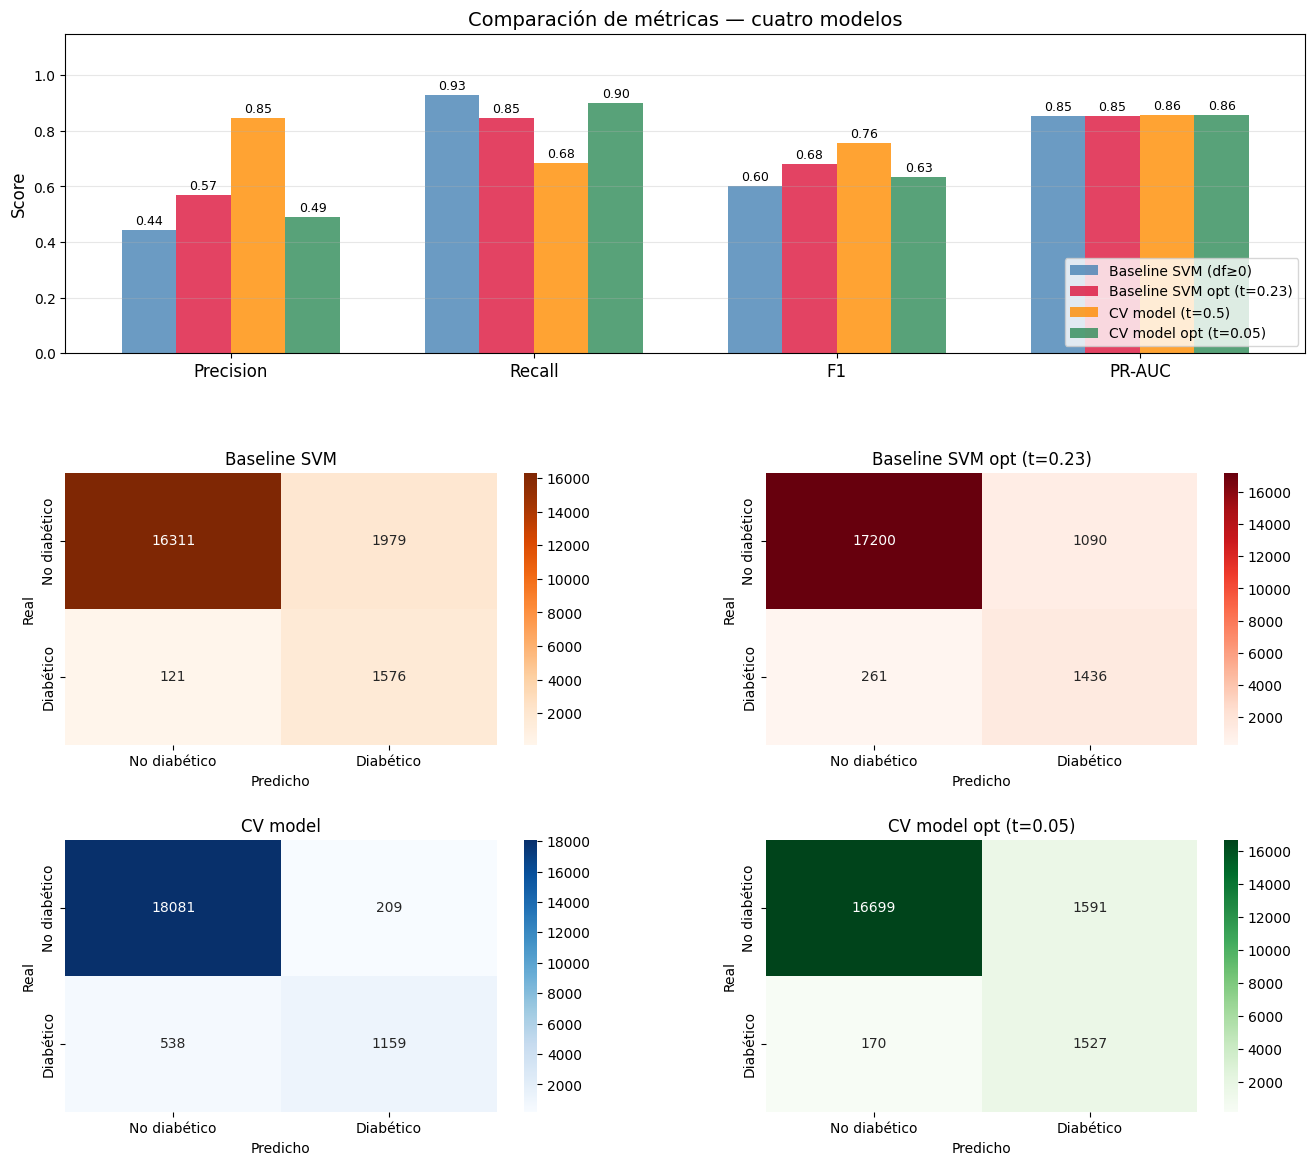

Guardado: cv_comparison.png


In [30]:
import joblib
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix

# -------------------------------------------------------------------------
# Importamos el diccionario de métricas del baseline optimizado (si existen)
# -------------------------------------------------------------------------
try:
    baseline_thr_opt = json.load(open(r'C:\Users\juaji\AFI\trabajo_grupal_2\SVM_model\artifacts\metrics_baseline_optimized.json'))
    print("Archivo de métricas del baseline optimizado cargado correctamente.")
except FileNotFoundError:
    baseline_thr_opt = {}
    print("Archivo de métricas del baseline optimizado no encontrado.")

# Métricas del baseline optimizado (fallback a valores por defecto si no existe)
cm_base_opt = baseline_thr_opt.get('cm', None)

# Importamos el modelo baseline si no lo tenemos:

if not 'baseline_model' in dir():
    baseline_model = joblib.load("artifacts\\svm_model_trained.pkl")
    print('Modelo base cargado desde disco.')
    

# -------------------------------------------------------------------------
# PREDICCIONES
# -------------------------------------------------------------------------

# Baseline
y_pred_base  = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:,1]

# Baseline optimizado
base_opt_threshold = baseline_thr_opt.get('threshold', 0.5)
y_pred_base_opt = (y_proba_base >= base_opt_threshold).astype(int)

# Modelo CV
y_pred_cv_05 = (y_proba >= 0.5).astype(int)

best_threshold = best_t["threshold"]
y_pred_cv_opt = (y_proba >= best_threshold).astype(int)

# -------------------------------------------------------------------------
# MÉTRICAS
# -------------------------------------------------------------------------
def get_metrics(y_true, y_pred, y_score):
    return {
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "PR-AUC":    average_precision_score(y_true, y_score),
    }

base_metrics = get_metrics(
    y_test,
    y_pred_base,
    y_proba_base
)
base_opt_metrics = get_metrics(
    y_test,
    y_pred_base_opt,
    y_proba_base
)
cv05_metrics = get_metrics(
    y_test,
    y_pred_cv_05,
    y_proba
)
opt_metrics = get_metrics(
    y_test,
    y_pred_cv_opt,
    y_proba
)

# -------------------------------------------------------------------------
# MATRICES DE CONFUSIÓN
# -------------------------------------------------------------------------
cm_base     = confusion_matrix(y_test, y_pred_base)
cm_base_opt = confusion_matrix(y_test, y_pred_base_opt)
cm_cv_05    = confusion_matrix(y_test, y_pred_cv_05)
cm_cv_opt   = confusion_matrix(y_test, y_pred_cv_opt)

# -------------------------------------------------------------------------
# FIGURA: 1 fila de barras + cuadrícula 2×2 de heatmaps
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2], hspace=0.25)

# ── Fila 0: gráfico de barras (4 modelos) ──
ax_bar = fig.add_subplot(gs[0])

metrics_names = ['Precision', 'Recall', 'F1', 'PR-AUC']
x = np.arange(len(metrics_names))
w = 0.18  # ancho de barra ajustado para 4 grupos

base_vals     = [base_metrics[m]     for m in metrics_names]
base_opt_vals = [base_opt_metrics[m] for m in metrics_names]
cv05_vals     = [cv05_metrics[m]     for m in metrics_names]
opt_vals      = [opt_metrics[m]      for m in metrics_names]

ax_bar.bar(x - 1.5*w, base_vals,     w, label='Baseline SVM (df≥0)',                  color='steelblue',  alpha=0.8)
ax_bar.bar(x - 0.5*w, base_opt_vals, w, label=f'Baseline SVM opt (t={base_opt_threshold:.2f})', color='crimson',    alpha=0.8)
ax_bar.bar(x + 0.5*w, cv05_vals,     w, label='CV model (t=0.5)',                     color='darkorange', alpha=0.8)
ax_bar.bar(x + 1.5*w, opt_vals,      w, label=f'CV model opt (t={best_threshold:.2f})',  color='seagreen',   alpha=0.8)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metrics_names, fontsize=12)
ax_bar.set_ylim([0, 1.15])
ax_bar.set_ylabel('Score', fontsize=12)
ax_bar.set_title('Comparación de métricas — cuatro modelos', fontsize=14)
ax_bar.legend(fontsize=10, loc='lower right')
ax_bar.grid(axis='y', alpha=0.3)

for bars in ax_bar.containers:
    ax_bar.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)

# ── Fila 1: heatmaps 2×2 ──
gs_bottom = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[1], hspace=0.35, wspace=0.3)

labels = ['No diabético', 'Diabético']

ax_cm1 = fig.add_subplot(gs_bottom[0, 0])
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Oranges', ax=ax_cm1,
            xticklabels=labels, yticklabels=labels)
ax_cm1.set_title('Baseline SVM', fontsize=12)
ax_cm1.set_xlabel('Predicho')
ax_cm1.set_ylabel('Real')

ax_cm2 = fig.add_subplot(gs_bottom[0, 1])
sns.heatmap(cm_base_opt, annot=True, fmt='d', cmap='Reds', ax=ax_cm2,
            xticklabels=labels, yticklabels=labels)
ax_cm2.set_title(f'Baseline SVM opt (t={base_opt_threshold:.2f})', fontsize=12)
ax_cm2.set_xlabel('Predicho')
ax_cm2.set_ylabel('Real')

ax_cm3 = fig.add_subplot(gs_bottom[1, 0])
sns.heatmap(cm_cv_05, annot=True, fmt='d', cmap='Blues', ax=ax_cm3,
            xticklabels=labels, yticklabels=labels)
ax_cm3.set_title('CV model', fontsize=12)
ax_cm3.set_xlabel('Predicho')
ax_cm3.set_ylabel('Real')

ax_cm4 = fig.add_subplot(gs_bottom[1, 1])
sns.heatmap(cm_cv_opt, annot=True, fmt='d', cmap='Greens', ax=ax_cm4,
            xticklabels=labels, yticklabels=labels)
ax_cm4.set_title(f'CV model opt (t={best_threshold:.2f})', fontsize=12)
ax_cm4.set_xlabel('Predicho')
ax_cm4.set_ylabel('Real')

plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: cv_comparison.png')

## 13. Resumen

In [71]:
print("=== y_pred_base ===")
unique, counts = np.unique(y_pred_base, return_counts=True)
print(dict(zip(unique, counts)))   # cuántos predice como 0 y como 1

print("\n=== Métricas baseline ===")
print(f"Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_base):.4f}")

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred_base))

=== y_pred_base ===
{np.int64(0): np.int64(16432), np.int64(1): np.int64(3555)}

=== Métricas baseline ===
Precision : 0.4433
Recall    : 0.9287
F1        : 0.6002

=== Classification report ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     18290
           1       0.44      0.93      0.60      1697

    accuracy                           0.89     19987
   macro avg       0.72      0.91      0.77     19987
weighted avg       0.95      0.89      0.91     19987



In [ ]:
print(f"""\nResumen:
  Métrica optimizada: Average Precision (PR-AUC)
  Parámetros óptimos: {grid_search.best_params_}
  Mejor Average Precision (CV): {grid_search.best_score_:.4f}\n
Test final:
  Precision: {precision:.4f}
  Recall:    {recall:.4f}
  F1:        {f1:.4f}
  PR-AUC:    {pr_auc:.4f}
  ROC-AUC:   {roc_auc:.4f}
  FN:        {fn}  (casos de diabetes no detectados)\n
Objetivo Recall >= 90%: {'CUMPLIDO' if recall >= 0.9 else 'NO CUMPLIDO'}
""")


Resumen:
  Métrica optimizada: Average Precision (PR-AUC)
  Parámetros óptimos: {'svm__C': 1, 'svm__class_weight': {0: 1, 1: 5}, 'svm__gamma': 'scale'}
  Mejor Average Precision (CV): 0.8307

Test final:
  Precision: 0.6358
  Recall:    0.8167
  F1:        0.7150
  PR-AUC:    0.8558
  ROC-AUC:   0.9701
  FN:        311  (casos de diabetes no detectados)

Objetivo Recall >= 90%: NO CUMPLIDO

